# Waste Type Identification — Esperimento 3: Augmentation Geometrica/Strutturale

**Una sola variabile, due livelli** (interruttore `GEO_LEVEL`):
- `'rrc'`: light + RandomResizedCrop. Introduce variazioni di inquadratura, scala e viste
  parziali.
- `'rrc_cutmix'`: rrc + CutMix nel training loop. Aggiunge occlusione e mescolamento di
  regioni, che simulano clutter e oggetti parzialmente coperti.

> La loss resta CrossEntropy **semplice**: l'Esperimento 2 ha mostrato che pesarla è neutra,
> quindi la teniamo fuori per isolare la geometria come unica variabile.

## 1. Configurazione

**Cambiare solo `GEO_LEVEL`** per passare da un run all'altro. Tutto il resto è identico
alla baseline.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path

GEO_LEVEL = 'rrc_cutmix'                                                        # 'rrc' oppure 'rrc_cutmix'

# Percorsi
BASE = Path('/content/drive/MyDrive/2026_MLinf_gr41/Waste-Project')
DRIVE_DATASET_DIR = BASE / 'dataset'
DATASET_DIR = Path('/content/dataset_local')
SPLIT_CSV = BASE / 'splits' / 'split.csv'
MODELS_DIR = BASE / 'models'
RESULTS_DIR = BASE / 'results'
MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Iperparametri identici alla Baseline
IMG_SIZE = 224
BATCH_SIZE = 64
NUM_EPOCHS = 15
LR = 0.01
MOMENTUM = 0.9
WEIGHT_DECAY = 1e-4
NUM_CLASSES = 8
SEED = 1234

# Parametri specifici dell'esperimento
RRC_SCALE = (0.5, 1.0)
CUTMIX_ALPHA = 1.0
CUTMIX_PROB = 0.5

assert GEO_LEVEL in ('rrc', 'rrc_cutmix'), "GEO_LEVEL deve essere 'rrc' o 'rrc_cutmix'"
USE_CUTMIX = (GEO_LEVEL == 'rrc_cutmix')
TAG = f'geo_{GEO_LEVEL}'
print('Esperimento:', TAG, '| CutMix:', USE_CUTMIX)

Mounted at /content/drive
Esperimento: geo_rrc_cutmix | CutMix: True


In [ ]:
import random, time, math
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from tqdm.auto import tqdm
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, recall_score
import matplotlib.pyplot as plt

def set_seed(s):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)
set_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

CLASS_NAMES = ['battery','clothing','glass','metal','organic','papery','plastic','undifferentiated']
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

Device: cuda


## 2. Copia del dataset in locale


In [ ]:
import shutil
if not DATASET_DIR.exists():
    print('Copio il dataset in locale, attendi qualche minuto...')
    t0 = time.time()
    shutil.copytree(DRIVE_DATASET_DIR, DATASET_DIR)
    print(f'Copia completata in {time.time() - t0:.0f}s')
else:
    print('Copia locale gia presente:', DATASET_DIR)

Copio il dataset in locale, attendi qualche minuto...
Copia completata in 468s


## 3. Preprocessing: light + geometria

La pipeline di training parte dal `light` (flip + piccola rotazione + ColorJitter lieve) e
sostituisce il `Resize((224,224))` con `RandomResizedCrop(224, scale=(0.5,1.0))`: è questa
l'aggiunta geometrica. CutMix non è una transform per-campione (opera a livello di batch
mescolando due immagini e le loro etichette) e viene applicato nel training loop, non qui.

La validation usa la stessa transform deterministica della baseline (`Resize` senza crop),
così il numero di validazione resta confrontabile con tutti gli altri run.

In [ ]:
# Validation: deterministica, identica alla baseline (nessun crop)
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# Train: light + RandomResizedCrop (la geometria è l'unica aggiunta rispetto a 'light')
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=RRC_SCALE, ratio=(0.75, 1.3333)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.0),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
print(f'RandomResizedCrop scale={RRC_SCALE} | CutMix={"on" if USE_CUTMIX else "off"}')

RandomResizedCrop scale=(0.5, 1.0) | CutMix=on


## 4. Dataset e DataLoader

Nessun ribilanciamento: CE semplice e `shuffle=True`.

In [ ]:
class WasteDataset(Dataset):
    def __init__(self, df, root, transform):
        self.df = df.reset_index(drop=True)
        self.root = Path(root)
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, i):
        row = self.df.iloc[i]
        img = Image.open(self.root / row['filepath']).convert('RGB')
        return self.transform(img), int(row['label'])

df = pd.read_csv(SPLIT_CSV)
df_train = df[df['split'] == 'train'].copy()
df_val = df[df['split'] == 'val'].copy()
print(f'Train: {len(df_train)} | Val: {len(df_val)}')

train_ds = WasteDataset(df_train, DATASET_DIR, train_transform)
val_ds = WasteDataset(df_val, DATASET_DIR, val_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=2, pin_memory=True)

Train: 12413 | Val: 3102


## 5. Modello

Identico alla baseline: ResNet18 pre-addestrata su ImageNet, testa lineare a 8 output.

In [ ]:
def build_model():
    m = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    m.fc = nn.Linear(m.fc.in_features, NUM_CLASSES)
    return m

model = build_model().to(device)
criterion = nn.CrossEntropyLoss()                                               # semplice: la geometria è l'unica variabile
optimizer = torch.optim.SGD(model.parameters(), lr=LR,
                            momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 162MB/s]


## 6. CutMix (solo per `rrc_cutmix`)

CutMix incolla una regione rettangolare di un'altra immagine del batch sull'immagine
corrente e mescola le etichette in proporzione all'area scambiata. Simula occlusione e
clutter. Si applica con probabilità `CUTMIX_PROB` per batch. Nel run `rrc` questa funzione non viene usata.

In [ ]:
def rand_bbox(W, H, lam):
    cut_rat = math.sqrt(1.0 - lam)
    cut_w, cut_h = int(W * cut_rat), int(H * cut_rat)
    cx, cy = np.random.randint(W), np.random.randint(H)
    x1 = np.clip(cx - cut_w // 2, 0, W); x2 = np.clip(cx + cut_w // 2, 0, W)
    y1 = np.clip(cy - cut_h // 2, 0, H); y2 = np.clip(cy + cut_h // 2, 0, H)
    return x1, y1, x2, y2

def cutmix_batch(x, y):
    lam = np.random.beta(CUTMIX_ALPHA, CUTMIX_ALPHA)
    idx = torch.randperm(x.size(0), device=x.device)
    x1, y1, x2, y2 = rand_bbox(x.size(3), x.size(2), lam)
    x[:, :, y1:y2, x1:x2] = x[idx, :, y1:y2, x1:x2]
    lam = 1.0 - ((x2 - x1) * (y2 - y1) / (x.size(2) * x.size(3)))
    return x, y, y[idx], lam

## 7. Training

Loop identico alla baseline, con l'unica aggiunta del ramo CutMix (attivo solo se
`USE_CUTMIX`). Salviamo il modello migliore sulla valBalancedAccuracy con il suffisso del run
(`resnet18_geo_rrc.pth` / `resnet18_geo_rrc_cutmix.pth`). La validation è sempre su immagini
pulite (niente crop casuale, niente CutMix).

In [ ]:
def evaluate(model, loader):
    model.eval()
    all_pred, all_true = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device, non_blocking=True)
            all_pred.append(model(x).argmax(1).cpu())
            all_true.append(y)
    y_pred = torch.cat(all_pred).numpy()
    y_true = torch.cat(all_true).numpy()
    return balanced_accuracy_score(y_true, y_pred), y_true, y_pred

history = {'train_loss': [], 'val_balacc': []}
best_balacc = -1.0
best_path = MODELS_DIR / f'resnet18_{TAG}.pth'

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    running = 0.0
    for x, y in tqdm(train_loader, desc=f'epoch {epoch}/{NUM_EPOCHS} [{TAG}]'):
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        optimizer.zero_grad()
        if USE_CUTMIX and random.random() < CUTMIX_PROB:
            x, y_a, y_b, lam = cutmix_batch(x, y)
            out = model(x)
            loss = lam * criterion(out, y_a) + (1.0 - lam) * criterion(out, y_b)
        else:
            out = model(x)
            loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        running += loss.item() * x.size(0)
    scheduler.step()

    train_loss = running / len(train_ds)
    val_balacc, _, _ = evaluate(model, val_loader)
    history['train_loss'].append(train_loss)
    history['val_balacc'].append(val_balacc)
    print(f'  loss={train_loss:.4f}  val_balAcc={val_balacc:.4f}')

    if val_balacc > best_balacc:
        best_balacc = val_balacc
        torch.save(model.state_dict(), best_path)
        print(f'  -> nuovo best ({best_balacc:.4f}) salvato in {best_path.name}')

print(f'\nMiglior val Balanced Accuracy [{TAG}]: {best_balacc:.4f}')

epoch 1/15 [geo_rrc_cutmix]:   0%|          | 0/194 [00:00<?, ?it/s]

  loss=0.8367  val_balAcc=0.8663
  -> nuovo best (0.8663) salvato in resnet18_geo_rrc_cutmix.pth


epoch 2/15 [geo_rrc_cutmix]:   0%|          | 0/194 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7ff13f0d77e0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7ff13f0d77e0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

  loss=0.6226  val_balAcc=0.8938
  -> nuovo best (0.8938) salvato in resnet18_geo_rrc_cutmix.pth


...

  loss=0.3616  val_balAcc=0.9649
  -> nuovo best (0.9649) salvato in resnet18_geo_rrc_cutmix.pth


epoch 14/15 [geo_rrc_cutmix]:   0%|          | 0/194 [00:00<?, ?it/s]

  loss=0.3507  val_balAcc=0.9606


epoch 15/15 [geo_rrc_cutmix]:   0%|          | 0/194 [00:00<?, ?it/s]

  loss=0.3664  val_balAcc=0.9609

Miglior val Balanced Accuracy [geo_rrc_cutmix]: 0.9649


## 8. Curve di training

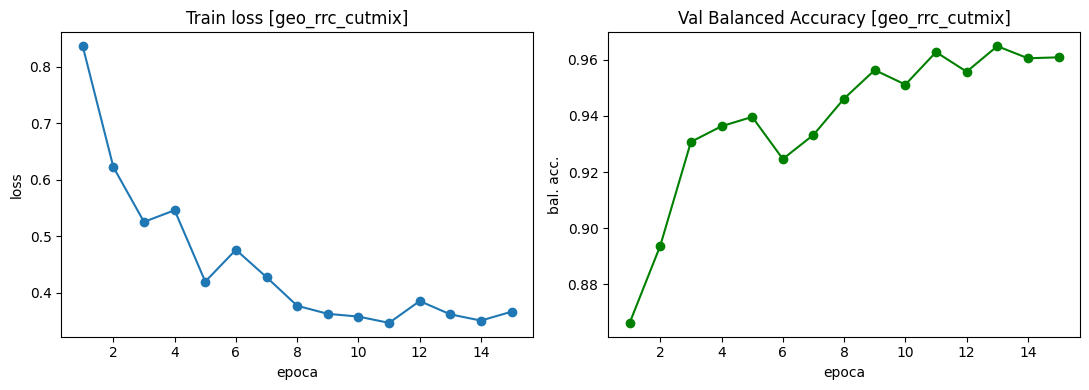

Salvato: /content/drive/MyDrive/2026_MLinf_gr41/Waste-Project/results/curves_geo_rrc_cutmix.png


In [ ]:
epochs = range(1, NUM_EPOCHS + 1)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(epochs, history['train_loss'], marker='o'); ax[0].set_title(f'Train loss [{TAG}]')
ax[0].set_xlabel('epoca'); ax[0].set_ylabel('loss')
ax[1].plot(epochs, history['val_balacc'], marker='o', color='green')
ax[1].set_title(f'Val Balanced Accuracy [{TAG}]'); ax[1].set_xlabel('epoca'); ax[1].set_ylabel('bal. acc.')
plt.tight_layout()
curves_path = RESULTS_DIR / f'curves_{TAG}.png'
plt.savefig(curves_path, dpi=120, bbox_inches='tight'); plt.show()
print('Salvato:', curves_path)

## 9. Analisi in-distribution: TPR per classe + matrice di confusione

[geo_rrc_cutmix] Val Balanced Accuracy: 0.9649

TPR per classe (in-distribution):
           class  label  tpr_val
         battery      0 0.984127
        clothing      1 0.997260
           glass      2 0.970149
           metal      3 0.941558
         organic      4 0.969543
          papery      5 0.971649
         plastic      6 0.913295
undifferentiated      7 0.971223
Salvato: /content/drive/MyDrive/2026_MLinf_gr41/Waste-Project/results/per_class_tpr_geo_rrc_cutmix.csv


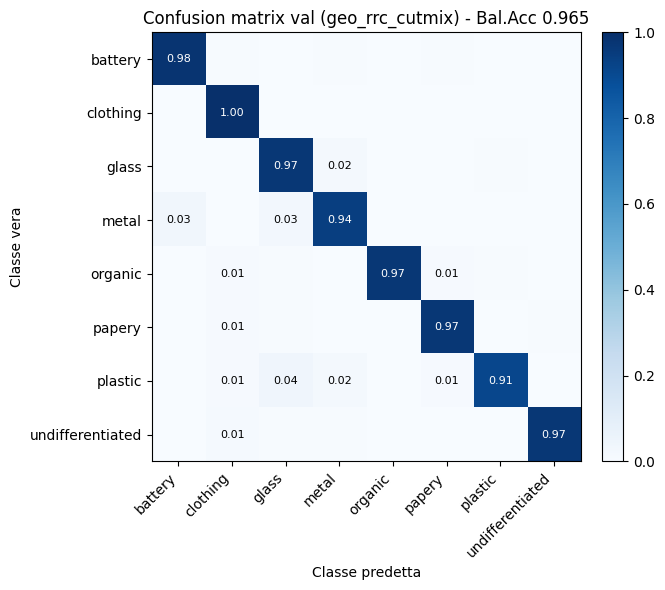

Salvato: /content/drive/MyDrive/2026_MLinf_gr41/Waste-Project/results/confusion_val_geo_rrc_cutmix.png


In [ ]:
model.load_state_dict(torch.load(best_path, map_location=device))
val_balacc, y_true, y_pred = evaluate(model, val_loader)
print(f'[{TAG}] Val Balanced Accuracy: {val_balacc:.4f}')

tpr = recall_score(y_true, y_pred, labels=list(range(NUM_CLASSES)), average=None, zero_division=0)
tpr_df = pd.DataFrame({'class': CLASS_NAMES, 'label': range(NUM_CLASSES), 'tpr_val': tpr})
tpr_csv = RESULTS_DIR / f'per_class_tpr_{TAG}.csv'
tpr_df.to_csv(tpr_csv, index=False)
print('\nTPR per classe (in-distribution):')
print(tpr_df.to_string(index=False))
print('Salvato:', tpr_csv)

cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)), normalize='true')
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, vmin=0, vmax=1, cmap='Blues')
ax.set_xticks(range(NUM_CLASSES)); ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
ax.set_yticks(range(NUM_CLASSES)); ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel('Classe predetta'); ax.set_ylabel('Classe vera')
ax.set_title(f'Confusion matrix val ({TAG}) - Bal.Acc {val_balacc:.3f}')
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        if cm[i, j] >= 0.01:
            ax.text(j, i, f'{cm[i, j]:.2f}', ha='center', va='center',
                    color='white' if cm[i, j] > 0.5 else 'black', fontsize=8)
fig.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout()
cm_path = RESULTS_DIR / f'confusion_val_{TAG}.png'
plt.savefig(cm_path, dpi=120, bbox_inches='tight'); plt.show()
print('Salvato:', cm_path)